# 6.26 - Counterfactual surrogate probe diagnostics

Train shallow decision trees directly on generated counterfactuals and evaluate whether they recover the original classifier's decision structure.

Protocol:
- training data: successful `x_cf` points produced by one method on one dataset
- training labels: `target_class`
- surrogate model: shallow decision tree
- evaluation set: real test split
- evaluation labels: original classifier predictions on the real test split

This is a classifier-fidelity probe: if a tree trained on a method's generated counterfactuals generalizes well to real test inputs, then those counterfactuals encode the target-class structure of the original model in a compact and learnable way.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from counterfactuals.datasets.loaders import (
    AdultDataset,
    CompasDataset,
    GermanCreditDataset,
    GiveMeSomeCreditDataset,
    HELOCDataset,
    LendingClubDataset,
    WisconsinBreastCancerDataset,
)
from scripts.benchmark import _build_torch_model_from_checkpoint

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 200)

RESULTS_DIR = ROOT / 'results'
CHECKPOINTS_DIR = ROOT / 'checkpoints'
RESULTS_DIR

PosixPath('/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results')

## Result Files

In [2]:
RESULT_FILES = {
    'main_l1': RESULTS_DIR / 'benchmark_full_reduced5000_L1.parquet',
    'face_german_credit': RESULTS_DIR / 'benchmark_face_german_credit.parquet',
    'face_compas': RESULTS_DIR / 'benchmark_face_compas.parquet',
    'face_wisconsin_breast_cancer': RESULTS_DIR / 'benchmark_face_wisconsin_breast_cancer.parquet',
    'face_give_me_some_credit': RESULTS_DIR / 'benchmark_face_give_me_some_credit.parquet',
    'face_lending_club': RESULTS_DIR / 'benchmark_face_lending_club.parquet',
    'face_heloc': RESULTS_DIR / 'benchmark_face_heloc.parquet',
}

FILE_STATUS_DF = pd.DataFrame([
    {
        'result_key': key,
        'path': str(path),
        'available': path.exists(),
        'size_mb': path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
    }
    for key, path in RESULT_FILES.items()
])

display(FILE_STATUS_DF)

missing = FILE_STATUS_DF.loc[~FILE_STATUS_DF['available'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing benchmark result files:\\n' + '\\n'.join(missing))

,result_key,path,available,size_mb
0,main_l1,/home/gabrielepintus/Documents/github/Preimage...,True,7.413036
1,face_german_credit,/home/gabrielepintus/Documents/github/Preimage...,True,0.112864
2,face_compas,/home/gabrielepintus/Documents/github/Preimage...,True,0.097081
3,face_wisconsin_breast_cancer,/home/gabrielepintus/Documents/github/Preimage...,True,0.087966
4,face_give_me_some_credit,/home/gabrielepintus/Documents/github/Preimage...,True,0.143084
5,face_lending_club,/home/gabrielepintus/Documents/github/Preimage...,True,0.148391
6,face_heloc,/home/gabrielepintus/Documents/github/Preimage...,True,0.170899


## Load And Normalize

In [3]:
frames = []
for result_key, path in RESULT_FILES.items():
    frame = pd.read_parquet(path).copy()
    frame['result_key'] = result_key
    frame['result_file'] = path.name
    if 'run_name' not in frame.columns:
        frame['run_name'] = frame['method'].astype(str)
    frames.append(frame)

BENCHMARK_DF = pd.concat(frames, ignore_index=True)

METHOD_LABELS = {
    'nearest_neighbor': 'NN',
    'growing_spheres': 'Growing Spheres',
    'dice': 'DiCE',
    'face': 'FACE',
}

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

METHOD_ORDER = [
    'CertCF alpha=0.25',
    'CertCF alpha=0.45',
    'CertCF alpha=0.65',
    'CertCF alpha=0.85',
    'CertCF alpha=0.99',
    'NN',
    'Growing Spheres',
    'DiCE',
    'FACE',
]

PALETTE = {
    'CertCF alpha=0.25': '#0B7285',
    'CertCF alpha=0.45': '#1098AD',
    'CertCF alpha=0.65': '#15AABF',
    'CertCF alpha=0.85': '#22B8CF',
    'CertCF alpha=0.99': '#66D9E8',
    'NN': '#495057',
    'Growing Spheres': '#F08C00',
    'DiCE': '#C92A2A',
    'FACE': '#7048E8',
}


def method_label(row: pd.Series) -> str:
    if row['method'] == 'certcf':
        return str(row['run_name']).replace('certcf_eps_alpha=', 'CertCF alpha=')
    return METHOD_LABELS.get(str(row['method']), str(row['run_name']))

ANALYSIS_DF = BENCHMARK_DF.copy()
ANALYSIS_DF['method_label'] = ANALYSIS_DF.apply(method_label, axis=1)
ANALYSIS_DF['dataset'] = pd.Categorical(ANALYSIS_DF['dataset'], DATASET_ORDER, ordered=True)
ANALYSIS_DF['method_label'] = pd.Categorical(ANALYSIS_DF['method_label'], METHOD_ORDER, ordered=True)
ANALYSIS_DF = ANALYSIS_DF.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)

print({
    'rows': int(len(ANALYSIS_DF)),
    'datasets': sorted(ANALYSIS_DF['dataset'].dropna().astype(str).unique().tolist()),
    'methods': sorted(ANALYSIS_DF['method'].dropna().astype(str).unique().tolist()),
})

{'rows': 41957, 'datasets': ['adult', 'compas', 'german_credit', 'give_me_some_credit', 'heloc', 'lending_club', 'wisconsin_breast_cancer'], 'methods': ['certcf', 'dice', 'face', 'growing_spheres', 'nearest_neighbor']}


## Dataset And Model Helpers

In [4]:
DATASET_LOADERS = {
    'adult': AdultDataset,
    'compas': CompasDataset,
    'german_credit': GermanCreditDataset,
    'give_me_some_credit': GiveMeSomeCreditDataset,
    'heloc': HELOCDataset,
    'lending_club': LendingClubDataset,
    'wisconsin_breast_cancer': WisconsinBreastCancerDataset,
}

DATASET_CHECKPOINTS = {
    dataset: CHECKPOINTS_DIR / f'{dataset}_classifier' / 'best.ckpt'
    for dataset in DATASET_LOADERS
}

RUN_CFG = {
    'min_successes': 50,
    'logreg_max_iter': 4000,
    'tree_max_depth': 5,
    'tree_min_samples_leaf': 10,
    'random_state': 42,
}


def load_dataset_bundle(dataset_name: str):
    loader_cls = DATASET_LOADERS[dataset_name]
    loader = loader_cls(data_dir=str(ROOT / 'data'), seed=RUN_CFG['random_state'])
    loader.load()
    x_train, y_train = loader.get_train()
    x_test, _ = loader.get_test()
    checkpoint = DATASET_CHECKPOINTS[dataset_name]
    model = _build_torch_model_from_checkpoint(
        checkpoint=str(checkpoint),
        device='cpu',
        dataset_module=dataset_name,
    )
    y_model_test = model.predict(x_test).astype(np.int64)
    return {
        'x_train': x_train.astype(np.float32),
        'y_train': y_train.astype(np.int64),
        'x_test': x_test.astype(np.float32),
        'y_model_test': y_model_test,
        'n_features': int(x_test.shape[1]),
        'checkpoint': str(checkpoint),
    }


DATA_BUNDLES = {dataset: load_dataset_bundle(dataset) for dataset in DATASET_ORDER}

DATASET_INFO_DF = pd.DataFrame([
    {
        'dataset': dataset,
        'n_train': int(bundle['x_train'].shape[0]),
        'n_test': int(bundle['x_test'].shape[0]),
        'n_features': int(bundle['n_features']),
        'checkpoint': bundle['checkpoint'],
    }
    for dataset, bundle in DATA_BUNDLES.items()
])

display(DATASET_INFO_DF)

,dataset,n_train,n_test,n_features,checkpoint
0,adult,36178,4522,104,/home/gabrielepintus/Documents/github/Preimage...
1,compas,4938,617,14,/home/gabrielepintus/Documents/github/Preimage...
2,german_credit,800,100,61,/home/gabrielepintus/Documents/github/Preimage...
3,give_me_some_credit,120000,15000,10,/home/gabrielepintus/Documents/github/Preimage...
4,heloc,8369,1045,23,/home/gabrielepintus/Documents/github/Preimage...
5,lending_club,30823,3852,25,/home/gabrielepintus/Documents/github/Preimage...
6,wisconsin_breast_cancer,457,56,30,/home/gabrielepintus/Documents/github/Preimage...


## Surrogate Training And Evaluation

In [5]:
def compute_binary_auc(y_true: np.ndarray, positive_proba: np.ndarray) -> float:
    labels = np.unique(y_true)
    if len(labels) != 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, positive_proba))
    except ValueError:
        return np.nan


def evaluate_surrogate(model, x_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    y_pred = model.predict(x_eval)
    metrics = {
        'accuracy': float(accuracy_score(y_eval, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_eval, y_pred)),
        'macro_f1': float(f1_score(y_eval, y_pred, average='macro')),
    }
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(x_eval)
        if proba.ndim == 2 and proba.shape[1] == 2:
            metrics['roc_auc'] = compute_binary_auc(y_eval, proba[:, 1])
        else:
            metrics['roc_auc'] = np.nan
    else:
        metrics['roc_auc'] = np.nan
    return metrics


def fit_surrogates_for_group(group_df: pd.DataFrame, dataset_name: str) -> list[dict]:
    bundle = DATA_BUNDLES[dataset_name]
    n_features = bundle['n_features']
    cf_cols = [f'x_cf_{i}' for i in range(n_features)]
    success_df = group_df[group_df['success']].copy()
    if len(success_df) < RUN_CFG['min_successes']:
        return []

    x_cf = success_df[cf_cols].to_numpy(dtype=np.float32)
    y_cf = success_df['target_class'].to_numpy(dtype=np.int64)
    class_counts = pd.Series(y_cf).value_counts().sort_index()
    if len(class_counts) < 2:
        return []

    surrogate = DecisionTreeClassifier(
        max_depth=RUN_CFG['tree_max_depth'],
        min_samples_leaf=RUN_CFG['tree_min_samples_leaf'],
        class_weight='balanced',
        random_state=RUN_CFG['random_state'],
    )

    surrogate.fit(x_cf, y_cf)
    metrics = evaluate_surrogate(surrogate, bundle['x_test'], bundle['y_model_test'])
    return [{
        'dataset': dataset_name,
        'method': success_df['method'].iloc[0],
        'method_label': success_df['method_label'].iloc[0],
        'run_name': success_df['run_name'].iloc[0],
        'surrogate': 'tree',
        'eval_target': 'model_prediction',
        'n_cf_train': int(len(success_df)),
        'cf_class_0': int(class_counts.get(0, 0)),
        'cf_class_1': int(class_counts.get(1, 0)),
        **metrics,
    }]


rows = []
for (dataset_name, method_label), group_df in ANALYSIS_DF.groupby(['dataset', 'method_label'], observed=True, dropna=False):
    dataset_name = str(dataset_name)
    rows.extend(fit_surrogates_for_group(group_df, dataset_name))

SURROGATE_RESULTS_DF = pd.DataFrame(rows)
SURROGATE_RESULTS_DF['dataset'] = pd.Categorical(SURROGATE_RESULTS_DF['dataset'], DATASET_ORDER, ordered=True)
SURROGATE_RESULTS_DF['method_label'] = pd.Categorical(SURROGATE_RESULTS_DF['method_label'], METHOD_ORDER, ordered=True)
SURROGATE_RESULTS_DF = SURROGATE_RESULTS_DF.sort_values(
    ['dataset', 'eval_target', 'surrogate', 'method_label'],
    ignore_index=True,
)

## Best Tree Fidelity By Dataset

In [6]:
BEST_SURROGATE_DF = (
    SURROGATE_RESULTS_DF
    .sort_values(['dataset', 'balanced_accuracy', 'accuracy'], ascending=[True, False, False])
    .groupby(['dataset'], observed=True, as_index=False)
    .first()
)

display(BEST_SURROGATE_DF.round(4))

CERTCF_BEST_SURROGATE_DF = (
    SURROGATE_RESULTS_DF[SURROGATE_RESULTS_DF['method'].eq('certcf')]
    .sort_values(['dataset', 'balanced_accuracy', 'accuracy'], ascending=[True, False, False])
    .groupby(['dataset'], observed=True, as_index=False)
    .first()
)

BASELINE_BEST_SURROGATE_DF = (
    SURROGATE_RESULTS_DF[~SURROGATE_RESULTS_DF['method'].eq('certcf')]
    .sort_values(['dataset', 'balanced_accuracy', 'accuracy'], ascending=[True, False, False])
    .groupby(['dataset'], observed=True, as_index=False)
    .first()
)

CERTCF_SURROGATE_COMPARE_DF = CERTCF_BEST_SURROGATE_DF.merge(
    BASELINE_BEST_SURROGATE_DF,
    on=['dataset'],
    suffixes=('_certcf', '_baseline'),
)
CERTCF_SURROGATE_COMPARE_DF['balanced_accuracy_gap_certcf_minus_baseline'] = (
    CERTCF_SURROGATE_COMPARE_DF['balanced_accuracy_certcf'] - CERTCF_SURROGATE_COMPARE_DF['balanced_accuracy_baseline']
)
CERTCF_SURROGATE_COMPARE_DF['accuracy_gap_certcf_minus_baseline'] = (
    CERTCF_SURROGATE_COMPARE_DF['accuracy_certcf'] - CERTCF_SURROGATE_COMPARE_DF['accuracy_baseline']
)

display(CERTCF_SURROGATE_COMPARE_DF.round(4))

,dataset,method,method_label,run_name,surrogate,eval_target,n_cf_train,cf_class_0,cf_class_1,accuracy,balanced_accuracy,macro_f1,roc_auc
0,adult,nearest_neighbor,NN,nn,tree,model_prediction,1000,386,614,0.7360,0.7421,0.7281,0.7667
1,compas,certcf,CertCF alpha=0.99,certcf_eps_alpha=0.99,tree,model_prediction,617,271,346,0.8898,0.8881,0.8881,0.9217
2,german_credit,certcf,CertCF alpha=0.25,certcf_eps_alpha=0.25,tree,model_prediction,100,33,67,0.7400,0.7829,0.7348,0.7829
3,give_me_some_credit,certcf,CertCF alpha=0.45,certcf_eps_alpha=0.45,tree,model_prediction,1000,189,811,0.9564,0.9315,0.9307,0.9662
4,heloc,face,FACE,face,tree,model_prediction,937,470,467,0.8804,0.8812,0.8801,0.8810
5,lending_club,face,FACE,face,tree,model_prediction,990,463,527,0.7207,0.7096,0.7116,0.6725
6,wisconsin_breast_cancer,certcf,CertCF alpha=0.45,certcf_eps_alpha=0.45,tree,model_prediction,56,16,40,0.9107,0.8438,0.8780,0.8438


,dataset,method_certcf,method_label_certcf,run_name_certcf,surrogate_certcf,eval_target_certcf,n_cf_train_certcf,cf_class_0_certcf,cf_class_1_certcf,accuracy_certcf,balanced_accuracy_certcf,macro_f1_certcf,roc_auc_certcf,method_baseline,method_label_baseline,run_name_baseline,surrogate_baseline,eval_target_baseline,n_cf_train_baseline,cf_class_0_baseline,cf_class_1_baseline,accuracy_baseline,balanced_accuracy_baseline,macro_f1_baseline,roc_auc_baseline,balanced_accuracy_gap_certcf_minus_baseline,accuracy_gap_certcf_minus_baseline
0,adult,certcf,CertCF alpha=0.65,certcf_eps_alpha=0.65,tree,model_prediction,1000,386,614,0.7298,0.7373,0.7223,0.7498,nearest_neighbor,NN,nn,tree,model_prediction,1000,386,614,0.7360,0.7421,0.7281,0.7667,-0.0048,-0.0062
1,compas,certcf,CertCF alpha=0.99,certcf_eps_alpha=0.99,tree,model_prediction,617,271,346,0.8898,0.8881,0.8881,0.9217,nearest_neighbor,NN,nn,tree,model_prediction,617,271,346,0.8639,0.8598,0.8612,0.9002,0.0283,0.0259
2,german_credit,certcf,CertCF alpha=0.25,certcf_eps_alpha=0.25,tree,model_prediction,100,33,67,0.7400,0.7829,0.7348,0.7829,face,FACE,face,tree,model_prediction,97,31,66,0.7500,0.7365,0.7270,0.7343,0.0464,-0.0100
3,give_me_some_credit,certcf,CertCF alpha=0.45,certcf_eps_alpha=0.45,tree,model_prediction,1000,189,811,0.9564,0.9315,0.9307,0.9662,face,FACE,face,tree,model_prediction,986,194,792,0.9577,0.9299,0.9322,0.9666,0.0017,-0.0013
4,heloc,certcf,CertCF alpha=0.25,certcf_eps_alpha=0.25,tree,model_prediction,1000,533,467,0.8804,0.8750,0.8781,0.8916,face,FACE,face,tree,model_prediction,937,470,467,0.8804,0.8812,0.8801,0.8810,-0.0062,0.0000
5,lending_club,certcf,CertCF alpha=0.25,certcf_eps_alpha=0.25,tree,model_prediction,1000,456,544,0.6721,0.6659,0.6662,0.6900,face,FACE,face,tree,model_prediction,990,463,527,0.7207,0.7096,0.7116,0.6725,-0.0437,-0.0485
6,wisconsin_breast_cancer,certcf,CertCF alpha=0.45,certcf_eps_alpha=0.45,tree,model_prediction,56,16,40,0.9107,0.8438,0.8780,0.8438,face,FACE,face,tree,model_prediction,55,16,39,0.6250,0.5312,0.5317,0.5312,0.3125,0.2857


## Dataset Scoreboards

For each dataset, rank all methods by tree-surrogate fidelity to the original classifier.

In [7]:
SCOREBOARD_DF = (
    SURROGATE_RESULTS_DF
    .sort_values(['dataset', 'balanced_accuracy', 'macro_f1', 'accuracy'], ascending=[True, False, False, False])
    .reset_index(drop=True)
)
SCOREBOARD_DF['rank'] = (
    SCOREBOARD_DF.groupby('dataset', observed=True)['balanced_accuracy']
    .rank(method='min', ascending=False)
    .astype(int)
)

SCOREBOARD_TABLE_DF = SCOREBOARD_DF[[
    'dataset',
    'rank',
    'method_label',
    'run_name',
    'n_cf_train',
    'cf_class_0',
    'cf_class_1',
    'balanced_accuracy',
    'macro_f1',
    'accuracy',
    'roc_auc',
]].copy()

for dataset in DATASET_ORDER:
    dataset_df = SCOREBOARD_TABLE_DF[SCOREBOARD_TABLE_DF['dataset'].astype(str).eq(dataset)].copy()
    if dataset_df.empty:
        continue
    print(dataset)
    display(dataset_df.reset_index(drop=True).round(4))


adult


,dataset,rank,method_label,run_name,n_cf_train,cf_class_0,cf_class_1,balanced_accuracy,macro_f1,accuracy,roc_auc
0,adult,1,NN,nn,1000,386,614,0.7421,0.7281,0.7360,0.7667
1,adult,2,CertCF alpha=0.65,certcf_eps_alpha=0.65,1000,386,614,0.7373,0.7223,0.7298,0.7498
2,adult,3,CertCF alpha=0.85,certcf_eps_alpha=0.85,1000,386,614,0.7358,0.7095,0.7125,0.7744
3,adult,4,CertCF alpha=0.99,certcf_eps_alpha=0.99,1000,386,614,0.7319,0.7076,0.7112,0.7558
4,adult,5,CertCF alpha=0.45,certcf_eps_alpha=0.45,998,386,612,0.7314,0.7086,0.7127,0.7700
5,adult,6,Growing Spheres,gs,316,137,179,0.6836,0.6924,0.7450,0.8061
6,adult,7,CertCF alpha=0.25,certcf_eps_alpha=0.25,1000,386,614,0.6664,0.5801,0.5871,0.6875
7,adult,8,DiCE,dice,898,377,521,0.4781,0.4536,0.5615,0.4984


compas


,dataset,rank,method_label,run_name,n_cf_train,cf_class_0,cf_class_1,balanced_accuracy,macro_f1,accuracy,roc_auc
0,compas,1,CertCF alpha=0.99,certcf_eps_alpha=0.99,617,271,346,0.8881,0.8881,0.8898,0.9217
1,compas,2,CertCF alpha=0.65,certcf_eps_alpha=0.65,617,271,346,0.8699,0.8724,0.8752,0.9414
2,compas,3,CertCF alpha=0.85,certcf_eps_alpha=0.85,617,271,346,0.8663,0.8711,0.8752,0.9093
3,compas,4,NN,nn,617,271,346,0.8598,0.8612,0.8639,0.9002
4,compas,5,CertCF alpha=0.45,certcf_eps_alpha=0.45,617,271,346,0.8179,0.8153,0.8169,0.8744
5,compas,6,Growing Spheres,gs,614,268,346,0.8101,0.8020,0.8023,0.8931
6,compas,7,FACE,face,614,268,346,0.7229,0.7254,0.7358,0.8932
7,compas,8,CertCF alpha=0.25,certcf_eps_alpha=0.25,613,271,342,0.6798,0.6750,0.6759,0.6328
8,compas,9,DiCE,dice,520,225,295,0.5558,0.4729,0.6094,0.3670


german_credit


...

,dataset,rank,method_label,run_name,n_cf_train,cf_class_0,cf_class_1,balanced_accuracy,macro_f1,accuracy,roc_auc
0,heloc,1,FACE,face,937,470,467,0.8812,0.8801,0.8804,0.8810
1,heloc,2,CertCF alpha=0.25,certcf_eps_alpha=0.25,1000,533,467,0.8750,0.8781,0.8804,0.8916
2,heloc,3,CertCF alpha=0.45,certcf_eps_alpha=0.45,1000,533,467,0.7625,0.7597,0.7789,0.7625
3,heloc,4,NN,nn,1000,533,467,0.7339,0.7311,0.7311,0.7852
4,heloc,5,DiCE,dice,919,452,467,0.6391,0.5714,0.6134,0.6689
5,heloc,6,Growing Spheres,gs,926,460,466,0.2726,0.2623,0.2833,0.2166


lending_club


,dataset,rank,method_label,run_name,n_cf_train,cf_class_0,cf_class_1,balanced_accuracy,macro_f1,accuracy,roc_auc
0,lending_club,1,FACE,face,990,463,527,0.7096,0.7116,0.7207,0.6725
1,lending_club,2,DiCE,dice,981,448,533,0.6941,0.6951,0.7017,0.8554
2,lending_club,3,CertCF alpha=0.25,certcf_eps_alpha=0.25,1000,456,544,0.6659,0.6662,0.6721,0.6900
3,lending_club,4,CertCF alpha=0.65,certcf_eps_alpha=0.65,1000,456,544,0.5838,0.5704,0.6155,0.6172
4,lending_club,5,NN,nn,1000,456,544,0.5744,0.5716,0.5735,0.6544
5,lending_club,6,CertCF alpha=0.45,certcf_eps_alpha=0.45,1000,456,544,0.5694,0.5685,0.5852,0.6234
6,lending_club,7,CertCF alpha=0.99,certcf_eps_alpha=0.99,1000,456,544,0.5601,0.5524,0.5857,0.7258
7,lending_club,8,Growing Spheres,gs,935,404,531,0.5494,0.5468,0.5680,0.6169
8,lending_club,9,CertCF alpha=0.85,certcf_eps_alpha=0.85,1000,456,544,0.5481,0.5270,0.5828,0.7291


wisconsin_breast_cancer


,dataset,rank,method_label,run_name,n_cf_train,cf_class_0,cf_class_1,balanced_accuracy,macro_f1,accuracy,roc_auc
0,wisconsin_breast_cancer,1,CertCF alpha=0.45,certcf_eps_alpha=0.45,56,16,40,0.8438,0.8780,0.9107,0.8438
1,wisconsin_breast_cancer,1,CertCF alpha=0.65,certcf_eps_alpha=0.65,56,16,40,0.8438,0.8780,0.9107,0.8438
2,wisconsin_breast_cancer,1,CertCF alpha=0.85,certcf_eps_alpha=0.85,56,16,40,0.8438,0.8780,0.9107,0.8438
3,wisconsin_breast_cancer,1,CertCF alpha=0.99,certcf_eps_alpha=0.99,56,16,40,0.8438,0.8780,0.9107,0.8438
4,wisconsin_breast_cancer,5,CertCF alpha=0.25,certcf_eps_alpha=0.25,56,16,40,0.8375,0.8439,0.8750,0.8117
5,wisconsin_breast_cancer,6,FACE,face,55,16,39,0.5312,0.5317,0.6250,0.5312
6,wisconsin_breast_cancer,7,NN,nn,56,16,40,0.5062,0.3700,0.3750,0.3141
7,wisconsin_breast_cancer,8,DiCE,dice,56,16,40,0.1250,0.1225,0.1250,0.0828


## Compact Tree-Fidelity Plots

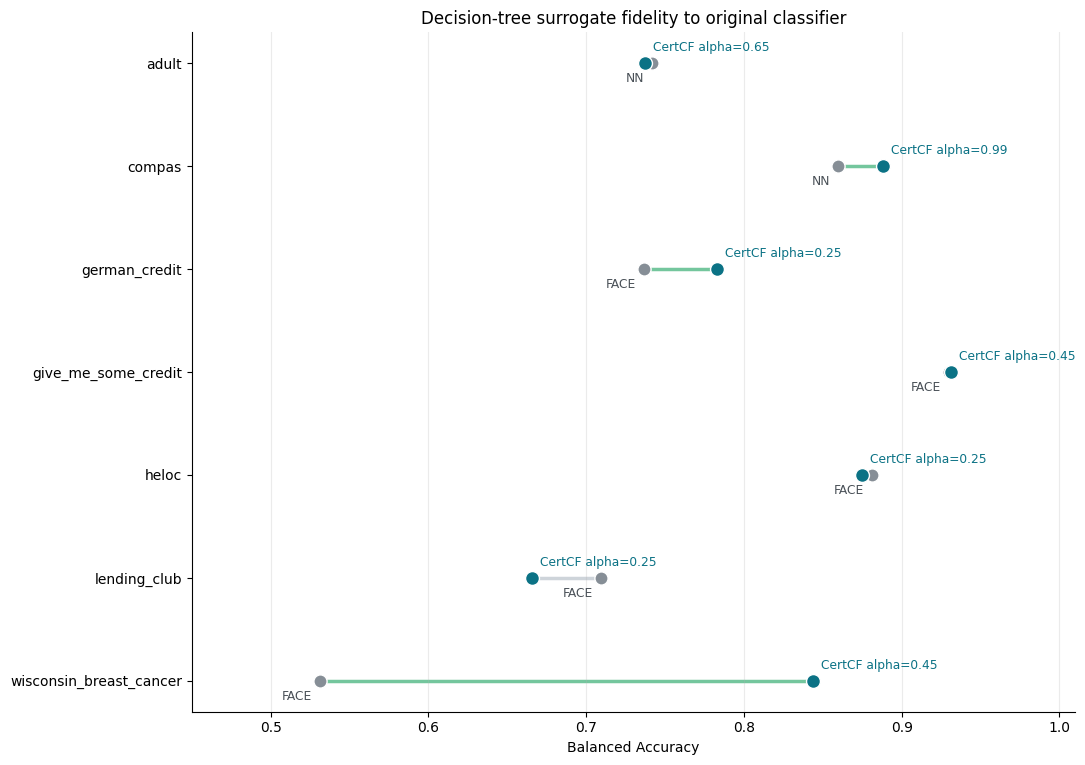

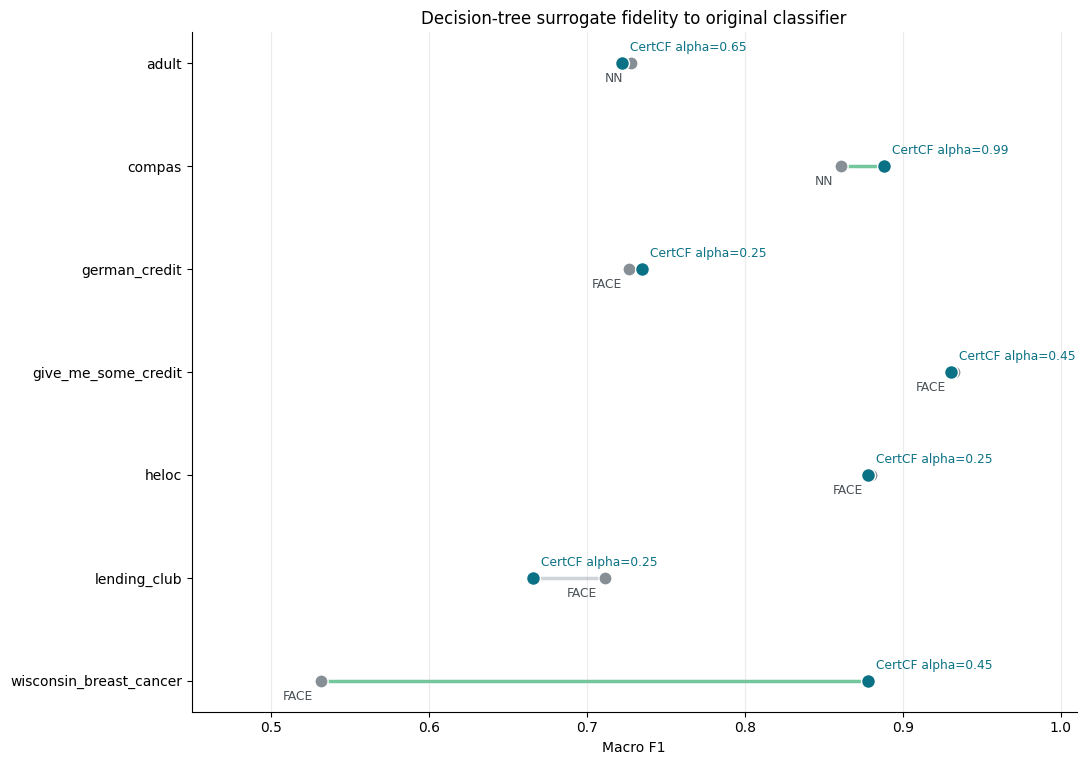

In [8]:
def plot_best_certcf_vs_baseline_surrogate(comp_df: pd.DataFrame, metric: str = 'balanced_accuracy'):
    plot_df = comp_df.copy()
    metric_certcf = f'{metric}_certcf'
    metric_baseline = f'{metric}_baseline'
    g = plot_df.copy().sort_values('dataset').iloc[::-1].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11, max(4.8, 0.85 * len(g) + 1.8)))
    y = np.arange(len(g))
    for i, row in g.iterrows():
            win = row[metric_certcf] > row[metric_baseline]
            line_color = '#74C69D' if win else '#CED4DA'
            ax.plot([row[metric_baseline], row[metric_certcf]], [i, i], color=line_color, linewidth=2.5, zorder=1)
            ax.scatter(row[metric_baseline], i, s=90, color='#868E96', edgecolor='white', linewidth=1.0, zorder=3)
            ax.scatter(row[metric_certcf], i, s=100, color='#0B7285', edgecolor='white', linewidth=1.0, zorder=4)
            ax.text(row[metric_baseline] - 0.005, i - 0.15, str(row['method_label_baseline']), ha='right', va='center', fontsize=8.8, color='#495057')
            ax.text(row[metric_certcf] + 0.005, i + 0.15, str(row['method_label_certcf']), ha='left', va='center', fontsize=8.8, color='#0B7285')
    ax.set_yticks(y)
    ax.set_yticklabels(g['dataset'])
    ax.set_xlim(0.45, 1.01)
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_title('Decision-tree surrogate fidelity to original classifier')
    ax.grid(True, axis='x', alpha=0.25)
    ax.grid(False, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    return fig


plot_best_certcf_vs_baseline_surrogate(CERTCF_SURROGATE_COMPARE_DF, metric='balanced_accuracy');

plot_best_certcf_vs_baseline_surrogate(CERTCF_SURROGATE_COMPARE_DF, metric='macro_f1');